# Buscar en un mapa: BFS, DFS, coste uniforme y A\*

**Facsímil 2 · Inteligencia clásica** — capítulos 1 a 3
(búsqueda como espacio de estados, algoritmos ciegos, y A\* con heurísticas).

Antes de los LLM, *esto* era la inteligencia artificial: representar un problema como un espacio de
estados y buscar dentro de él. Y sigue estando por debajo de un GPS, de un planificador de tareas o
de un agente que decide pasos hacia un objetivo. En este cuaderno sueltas un repartidor en una
ciudad-cuadrícula con calles cortadas y comparas cuatro algoritmos de búsqueda. No solo si encuentran
la ruta: **cuánto tienen que mirar** para encontrarla. Esa diferencia —entre buscar a ciegas y buscar
con criterio— es una de las ideas más rentables de toda la informática.

### Qué vas a aprender
- Qué es un **espacio de estados** y por qué casi cualquier problema puede plantearse como una
  búsqueda en él.
- Cómo cuatro algoritmos (**BFS, DFS, coste uniforme y A\***) exploran ese espacio de formas
  distintas, y qué **garantiza** cada uno (¿encuentra solución? ¿la óptima? ¿a qué coste?).
- Qué es una **heurística** y por qué una buena convierte una búsqueda imposible en una instantánea.
- Qué significa que una heurística sea **admisible**, y qué pasa si dejas de serlo (lo verás con un
  experimento).

### Cuánto cuesta
Unos 12 minutos. CPU, solo librería estándar y Matplotlib.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
import heapq
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# Una explanada grande con un edificio en medio que hay que rodear. En campo
# abierto se ve clarisimo quien busca a ciegas y quien busca con criterio.
GRID = np.zeros((20, 32), dtype=int)   # 0 = calle, 1 = obstaculo
GRID[5:15, 11:21] = 1                   # el edificio central
INICIO, META = (18, 2), (1, 29)
print("Mapa de", GRID.shape, "casillas. Inicio:", INICIO, " Meta:", META)


Mapa de (20, 32) casillas. Inicio: (18, 2)  Meta: (1, 29)


## 1. Buscar = explorar un espacio de estados

Casi cualquier problema de decisión puede plantearse así: hay **estados** (situaciones), un estado
**inicial**, uno o varios estados **meta**, y **acciones** que llevan de un estado a otro con un
cierto coste. Resolver el problema es encontrar una secuencia de acciones del inicial a la meta. En
nuestro mapa, cada casilla es un estado; las acciones son moverse a una casilla vecina (arriba, abajo,
izquierda, derecha) si no es un muro.

La pregunta no es solo «¿hay camino?», sino «¿cuántos estados tienes que **expandir** (mirar) para
dar con él?». En problemas reales el espacio de estados es astronómico (un ajedrez tiene más estados
que átomos hay en el universo observable), así que *cuánto* exploras lo es todo.


In [2]:
def vecinos(p):
    f, c = p
    for df, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        nf, nc = f+df, c+dc
        if 0 <= nf < GRID.shape[0] and 0 <= nc < GRID.shape[1] and GRID[nf, nc] == 0:
            yield (nf, nc)

def reconstruir(padre, fin):
    camino = [fin]
    while camino[-1] in padre:
        camino.append(padre[camino[-1]])
    return camino[::-1]


## 2. Cuatro formas de explorar, y qué garantiza cada una

La diferencia entre los algoritmos está en **el orden** en que sacan estados de la frontera (los
candidatos por explorar). Y ese orden depende de una estructura de datos:

| Algoritmo | Estructura | ¿Encuentra solución? | ¿La más corta? | Idea |
|---|---|---|---|---|
| **BFS** (anchura) | cola (FIFO) | sí | **sí** (en pasos) | explora por capas, como una onda |
| **DFS** (profundidad) | pila (LIFO) | sí | **no** | tira por un camino hasta el fondo |
| **Coste uniforme (UCS)** | cola de prioridad por coste | sí | **sí** (en coste) | como BFS pero ordenando por coste acumulado |
| **A\*** | cola de prioridad por coste + heurística | sí | **sí** (si la heurística es admisible) | va *hacia* la meta, no en todas direcciones |

La clave de A\* es la **heurística** $h(n)$: una estimación de lo que falta desde $n$ hasta la meta.
A\* ordena la frontera por $f(n) = g(n) + h(n)$, donde $g$ es el coste ya recorrido. Usaremos la
**distancia de Manhattan** (cuántas casillas en horizontal más en vertical), que en una cuadrícula
nunca sobreestima: es *admisible*, y por eso A\* sigue dando el camino óptimo.


In [3]:
def bfs(inicio, meta):
    frontera = deque([inicio]); padre = {}; vistos = {inicio}; expandidos = 0
    while frontera:
        n = frontera.popleft(); expandidos += 1
        if n == meta: return reconstruir(padre, meta), expandidos, vistos
        for v in vecinos(n):
            if v not in vistos:
                vistos.add(v); padre[v] = n; frontera.append(v)
    return None, expandidos, vistos

def dfs(inicio, meta):
    pila = [inicio]; padre = {}; vistos = {inicio}; expandidos = 0
    while pila:
        n = pila.pop(); expandidos += 1
        if n == meta: return reconstruir(padre, meta), expandidos, vistos
        for v in vecinos(n):
            if v not in vistos:
                vistos.add(v); padre[v] = n; pila.append(v)
    return None, expandidos, vistos

def ucs(inicio, meta):
    pq = [(0, inicio)]; padre = {}; coste = {inicio: 0}; expandidos = 0; vistos = set()
    while pq:
        g, n = heapq.heappop(pq)
        if n in vistos: continue
        vistos.add(n); expandidos += 1
        if n == meta: return reconstruir(padre, meta), expandidos, vistos
        for v in vecinos(n):
            ng = g + 1
            if ng < coste.get(v, 1e9):
                coste[v] = ng; padre[v] = n; heapq.heappush(pq, (ng, v))
    return None, expandidos, vistos

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def astar(inicio, meta, h=manhattan, desempate=True):
    # Con desempate guardamos -g (preferimos el nodo mas avanzado ante igual f):
    # asi A* avanza en un haz en vez de expandir todo el abanico de caminos empatados.
    pq = [(h(inicio, meta), 0, inicio)]; padre = {}; coste = {inicio: 0}
    expandidos = 0; vistos = set()
    while pq:
        f, g_key, n = heapq.heappop(pq); g = -g_key if desempate else g_key
        if n in vistos: continue
        vistos.add(n); expandidos += 1
        if n == meta: return reconstruir(padre, meta), expandidos, vistos
        for v in vecinos(n):
            ng = g + 1
            if ng < coste.get(v, 1e9):
                coste[v] = ng; padre[v] = n
                heapq.heappush(pq, (ng + h(v, meta), -ng if desempate else ng, v))
    return None, expandidos, vistos

resultados = {}
for nombre, fn in [("BFS", bfs), ("DFS", dfs), ("UCS", ucs), ("A*", astar)]:
    camino, expandidos, vistos = fn(INICIO, META)
    resultados[nombre] = (camino, expandidos, vistos)
    print(f"{nombre:4}  ->  camino de {len(camino):3} pasos   |   casillas miradas: {expandidos}")


BFS   ->  camino de  45 pasos   |   casillas miradas: 532
DFS   ->  camino de 151 pasos   |   casillas miradas: 365
UCS   ->  camino de  45 pasos   |   casillas miradas: 532
A*    ->  camino de  45 pasos   |   casillas miradas: 45


**Lee la tabla.** BFS, UCS y A\* encuentran el mismo camino óptimo (mismo número de pasos), pero
fíjate en *casillas miradas*: A\* mira una fracción de lo que mira BFS, porque su heurística lo empuja
hacia la meta en vez de explorar en todas direcciones (con un buen desempate llega a mirar casi solo
las casillas del propio camino). DFS, en cambio, llega rápido a *algo*, pero su ruta es larguísima:
se mete por un pasillo y no vuelve aunque haya algo mejor. **Rapidez no es lo mismo que calidad.**


## 3. Verlo: qué exploró cada uno

Pintamos en gris las casillas que cada algoritmo tuvo que mirar, y en negro el camino final. La nube
gris de BFS llena medio mapa; la de A\* es un haz dirigido a la meta. Esa es, en una imagen, la
diferencia entre fuerza bruta y criterio.


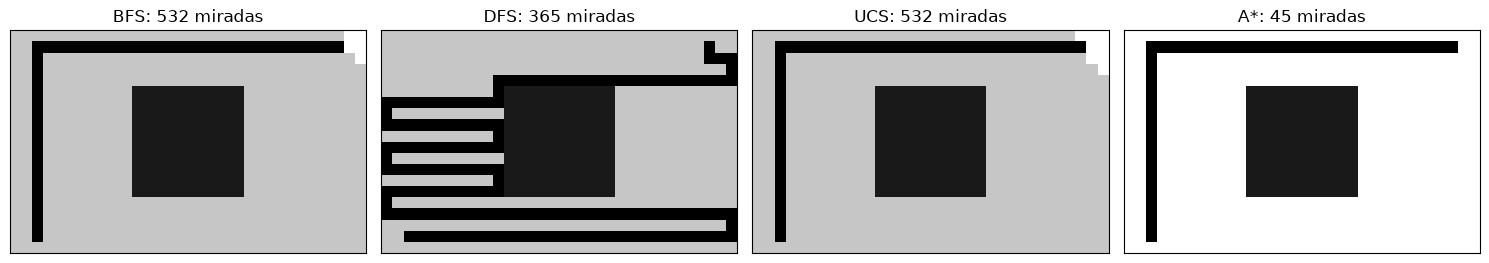

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
for ax, nombre in zip(axes, ["BFS", "DFS", "UCS", "A*"]):
    camino, expandidos, vistos = resultados[nombre]
    lienzo = np.ones((*GRID.shape, 3))
    lienzo[GRID == 1] = [0.1, 0.1, 0.1]
    for (f, c) in vistos: lienzo[f, c] = [0.78, 0.78, 0.78]
    for (f, c) in camino: lienzo[f, c] = [0.0, 0.0, 0.0]
    ax.imshow(lienzo); ax.set_title(f"{nombre}: {expandidos} miradas")
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 4. El corazón de A\*: heurística admisible y desempate

A\* es bueno **gracias a** la heurística, pero solo si esta cumple una condición: ser **admisible**, es
decir, **nunca sobreestimar** el coste que falta. La distancia de Manhattan lo cumple (en línea recta
por la cuadrícula nunca es más que rodeando), y por eso A\* con Manhattan **garantiza el camino
óptimo**. Si usaras una heurística que sobreestima, A\* correría más pero podría devolverte un camino
peor: perderías la garantía. Esa es la regla de oro de las heurísticas.

Hay un segundo detalle, más sutil, que explica por qué A\* mira tan **poquísimas** casillas: el
**desempate**. En una cuadrícula hay muchísimos caminos óptimos empatados (todos los que avanzan
monótonamente hacia la meta miden lo mismo). Sin un criterio extra, A\* los expande **todos**, llenando
un rectángulo. Si, ante igual $f$, preferimos el nodo **más avanzado** (mayor $g$), A\* avanza en un haz
estrecho. Mismo resultado óptimo, una fracción del trabajo. Lo medimos comparando A\* con y sin ese
desempate.


In [5]:
print("variante de A*           | casillas miradas | longitud del camino | ¿óptimo?")
optimo = len(resultados["A*"][0])
for nombre, desemp in [("sin desempate", False), ("con desempate (mayor g)", True)]:
    camino, expandidos, _ = astar(INICIO, META, desempate=desemp)
    print(f"  {nombre:<23}|       {expandidos:>4}         |        {len(camino):>3}          |  "
          f"{'sí' if len(camino)==optimo else 'no'}")
print("\nAmbos dan el camino optimo, pero el desempate reduce drasticamente lo que A* explora:")
print("sin desempate expande casi todo el rectangulo de caminos empatados; con el, va en linea.")


variante de A*           | casillas miradas | longitud del camino | ¿óptimo?
  sin desempate          |        404         |         45          |  sí
  con desempate (mayor g)|         45         |         45          |  sí

Ambos dan el camino optimo, pero el desempate reduce drasticamente lo que A* explora:
sin desempate expande casi todo el rectangulo de caminos empatados; con el, va en linea.


**Lo que enseña ese experimento.** Las dos variantes encuentran el mismo camino óptimo, pero el
desempate recorta a una fracción las casillas exploradas. Sin él, A\* malgasta tiempo expandiendo
decenas de caminos que miden exactamente lo mismo; con él, elige uno y avanza. Es un recordatorio de
que en los algoritmos de búsqueda los **detalles de implementación** (qué sacas primero de la frontera)
pueden importar tanto como la idea general.


## 5. Pruébalo tú

1. **Mueve la meta** cerca del inicio. ¿Se acortan las diferencias entre BFS y A\*? La heurística luce
   más cuanto más lejos está el objetivo.
2. **Cambia la heurística** por la distancia euclídea (`((a[0]-b[0])**2+(a[1]-b[1])**2)**0.5`). Sigue
   siendo admisible en esta cuadrícula, pero ¿mira más o menos casillas que Manhattan?
3. **Añade más obstáculos** y observa a DFS: a veces se mete en un callejón y da un rodeo enorme. ¿Por
   qué BFS nunca hace eso?
4. **Búsqueda voraz:** haz que A\* ordene la frontera solo por la heurística $h$ (ignorando $g$). Mira
   aún menos casillas, pero ¿sigue dando el camino óptimo? Comprueba que la avaricia se paga.


## 6. Errores comunes

- **Creer que DFS es malo siempre.** DFS usa poquísima memoria y es ideal cuando cualquier solución
  vale o el árbol es muy profundo; lo que no garantiza es la *más corta*.
- **Usar una heurística inadmisible sin saberlo** y extrañarse de que A\* no dé el óptimo. Si tu
  heurística puede sobreestimar, pierdes la garantía.
- **Olvidar el desempate.** Sin él, A\* expande todo el «rectángulo» de caminos empatados; con un buen
  desempate, avanza en un haz. Lo viste en los números.
- **Confundir coste y pasos.** Aquí cada paso cuesta 1, así que «más corto» y «más barato» coinciden;
  con costes distintos por casilla, UCS y A\* siguen siendo óptimos, pero BFS ya no.


## 7. Qué te llevas

- Buscar es explorar un **espacio de estados**; todos estos algoritmos hacen eso, lo que cambia es *en
  qué orden* miran, y eso lo decide su estructura de datos (cola, pila, cola de prioridad).
- Cada uno ofrece **garantías** distintas: BFS/UCS/A\* dan el óptimo, DFS no; A\* lo da *y* mira mucho
  menos, **si** la heurística es admisible.
- Una **heurística** que estima «cuánto falta» convierte una búsqueda ciega en una dirigida. Es la idea
  que separa la fuerza bruta del criterio, y reaparece en cada sistema que planifica.
- La palanca **velocidad vs. optimalidad** (A\* ponderado) es una decisión de ingeniería, no un fallo.

**Para seguir:** el capítulo 4 conecta esto con agentes modernos (de algoritmo a *política*); los
capítulos 5-7, con CSP y restricciones; y verás A\* reaparecer cada vez que algo tenga que planificar
pasos hacia un objetivo, incluido un agente LLM.


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*